In [15]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

In [16]:
fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")

fake["label"] = "Fake"
true["label"] = "Real"

df = pd.concat([fake, true], ignore_index=True)

print(df.shape)
df.head()

(44898, 5)


,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",Fake
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",Fake
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",Fake
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",Fake
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",Fake


In [17]:
print(df["subject"].value_counts())
print(df["label"].value_counts())

subject
politicsNews       11272
worldnews          10145
News                9050
politics            6841
left-news           4459
Government News     1570
US_News              783
Middle-east          778
Name: count, dtype: int64
label
Fake    23481
Real    21417
Name: count, dtype: int64


In [18]:
subject_counts = pd.crosstab(df["subject"], df["label"])
subject_counts

label,Fake,Real
subject,,
Government News,1570,0
Middle-east,778,0
News,9050,0
US_News,783,0
left-news,4459,0
politics,6841,0
politicsNews,0,11272
worldnews,0,10145


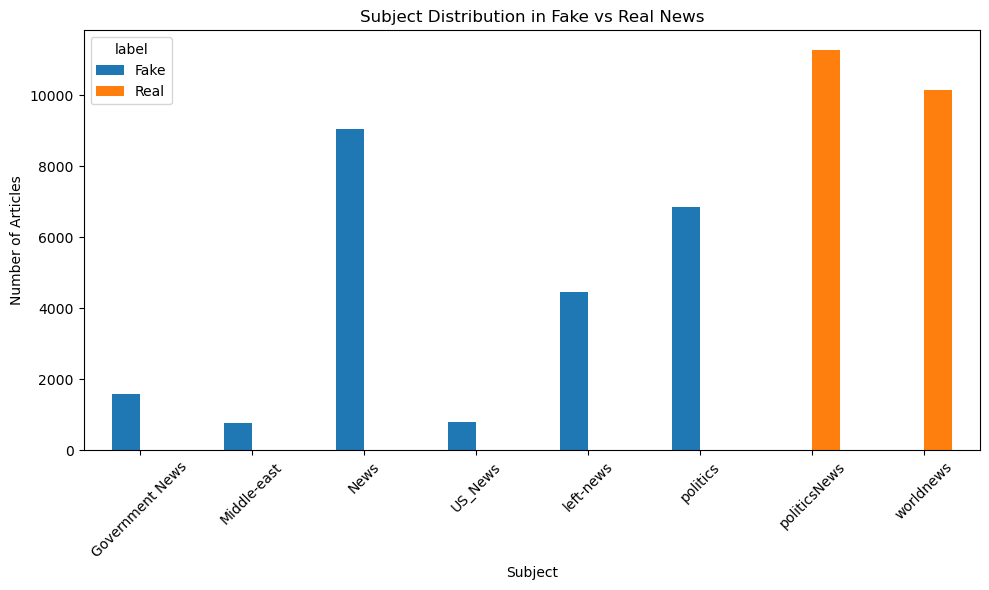

In [19]:
subject_counts.plot(kind="bar", figsize=(10, 6))
plt.title("Subject Distribution in Fake vs Real News")
plt.xlabel("Subject")
plt.ylabel("Number of Articles")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
df["text"] = df["text"].fillna("")

In [21]:
fake_texts = df[df["label"] == "Fake"]["text"]
real_texts = df[df["label"] == "Real"]["text"]

In [22]:
vectorizer_fake = CountVectorizer(stop_words="english", max_df=0.95, min_df=10)
X_fake = vectorizer_fake.fit_transform(fake_texts)

vectorizer_real = CountVectorizer(stop_words="english", max_df=0.95, min_df=10)
X_real = vectorizer_real.fit_transform(real_texts)

In [23]:
lda_fake = LatentDirichletAllocation(n_components=5, random_state=42)
lda_real = LatentDirichletAllocation(n_components=5, random_state=42)

lda_fake.fit(X_fake)
lda_real.fit(X_real)

,n_components,5
,doc_topic_prior,None
,topic_word_prior,None
,learning_method,'batch'
,learning_decay,0.7
,learning_offset,10.0
,max_iter,10
,batch_size,128
,evaluate_every,-1
,total_samples,1000000.0
,perp_tol,0.1


In [24]:
def print_topics(model, feature_names, n_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[-n_top_words:][::-1]]
        print(f"Topic {topic_idx + 1}: {', '.join(top_words)}")

print("Fake News Topics:")
print_topics(lda_fake, vectorizer_fake.get_feature_names_out())

print("\nReal News Topics:")
print_topics(lda_real, vectorizer_real.get_feature_names_out())

Fake News Topics:
Topic 1: media, government, war, american, new, world, state, syria, obama, military
Topic 2: said, police, black, people, video, just, man, year, told, gun
Topic 3: said, people, state, federal, obama, court, government, states, law, 000
Topic 4: trump, president, donald, people, just, said, like, obama, image, republican
Topic 5: clinton, trump, hillary, news, said, president, fbi, campaign, russia, russian

Real News Topics:
Topic 1: said, north, united, korea, state, military, states, nuclear, russia, trump
Topic 2: said, court, people, state, police, law, government, rights, states, case
Topic 3: said, percent, tax, year, government, party, election, people, million, new
Topic 4: said, china, minister, president, eu, party, european, government, prime, britain
Topic 5: trump, said, republican, house, president, clinton, senate, campaign, washington, white
